In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../')

from codes.Quantum import *
from codes.CSPSA import *

In [2]:
def postprocessing(U):
    U, _ = np.linalg.qr(U)
    # U = U@(U.T.conj()U).
    return U


def trineq(U, psi):
    Psi = triple_kron( psi, psi, psi )
    Psi = Psi.reshape(6*[2]).transpose([5,0,1,2,3,4]).flatten() 
    Rho = np.outer( Psi, Psi.conj() )

    U = postprocessing(U)

    M = []
    for u in U:
        M.append( np.outer(u,u.conj()) )

    probs = InnerProductMatrices( Rho, [ M, M, M ] ).real
    probs = probs.reshape(6*[2])

    probs_albl = np.sum( probs, axis=(1,3,4,5) )
    probs_alblclcr = np.sum( probs, axis=(1,3) )
    probs_clcr = np.sum( probs, axis=(0,1,2,3) )

    inequality = (-probs_albl[1,0] 
                +probs_alblclcr[1,0,1,0] 
                -probs_albl[0,1]*probs_clcr[1,0] 
                -probs_clcr[0,0]*probs_clcr[1,1] 
                -probs_clcr[0,1]*probs[1,0,0,1,1,0]
                -probs_clcr[0,1]*probs[1,1,0,0,1,0]
                +probs_clcr[0,0]*probs[1,0,1,1,1,1]
                +probs_clcr[0,0]*probs[1,1,1,0,1,1]
                +probs_clcr[1,0]*probs[0,0,1,0,0,1]
                +probs_clcr[1,0]*probs[0,1,1,1,0,1]
                +probs_clcr[1,1]*probs[0,0,0,0,0,0]
                +probs_clcr[1,1]*probs[0,1,0,1,0,0]
                )
    return inequality

In [49]:
gains = [4, 0, 0.1, 0.602, 0.101]
max_iter = 100
max_rep = 300
Out = []
iter = np.linspace(0.0, 0.5, 6)

Out = np.empty((max_rep, max_iter))

for i in range(6):
    a = i/10
    for k in range(max_rep):
        psi = np.sqrt(a)*np.array([[0, 1, 0, 0]]) + np.sqrt(1-a)*np.array([[0, 0, 1, 0]])
        U = np.random.randn(4,4) + 1j*np.random.randn(4,4)
        rho = psi.T.conj()@psi
        #rho = np.vdot(psi, psi) 
        # U = np.eye(4)
        #measure = RandomState( 4 )
        cspsa = CSPSA(gains=gains, minimize=False)
        
        results = cspsa.minimize(trineq, rho, max_iter,args = (psi), postprocessing=postprocessing)
        infidelities = results.fun

        Out[k, :] = infidelities
    
    np.save("Data_sim_0"+str(i), Out)

In [4]:
np.max(Out[0,0]), np.max(Out[5,0])

(np.float64(-0.3457857726066535), np.float64(-0.2430472936215364))

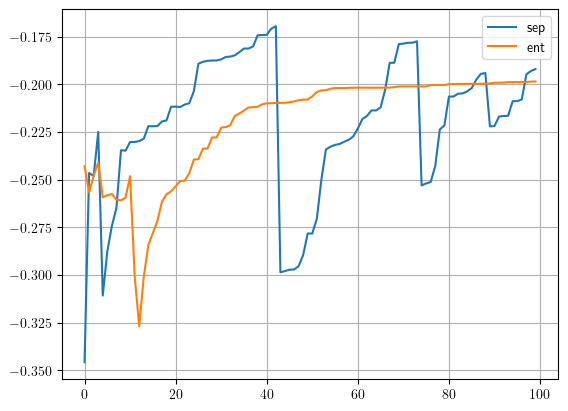

In [5]:
plt.plot(Out[0,:], label = 'sep' )
plt.plot(Out[5,:], label = 'ent' )
plt.legend()
plt.grid()

In [13]:
Load = "Data_sim_00.npy"
Data = np.load(Load)

array([[ 0.00000000e+00, -1.19906447e-02, -2.93198044e-02, ...,
        -1.15278604e-04, -8.62857989e-05, -8.30061761e-05],
       [ 0.00000000e+00, -1.15275229e-02, -1.62590642e-01, ...,
        -8.52929361e-05, -1.08027274e-04, -1.07294122e-04],
       [ 0.00000000e+00,  0.00000000e+00, -6.17228409e-03, ...,
        -4.53795056e-05, -4.56370482e-05, -4.43875112e-05],
       ...,
       [ 0.00000000e+00, -1.22057839e-02, -7.72038455e-02, ...,
        -1.03033251e-04, -5.70996044e-05, -4.59608288e-05],
       [ 0.00000000e+00, -1.40819000e-02, -2.59601860e-02, ...,
        -8.55135804e-05, -6.14961973e-05, -1.83593188e-04],
       [ 0.00000000e+00, -1.11278579e-09, -1.74742665e-02, ...,
        -1.41499668e-05, -1.51417973e-05, -1.14309349e-05]],
      shape=(50, 100))

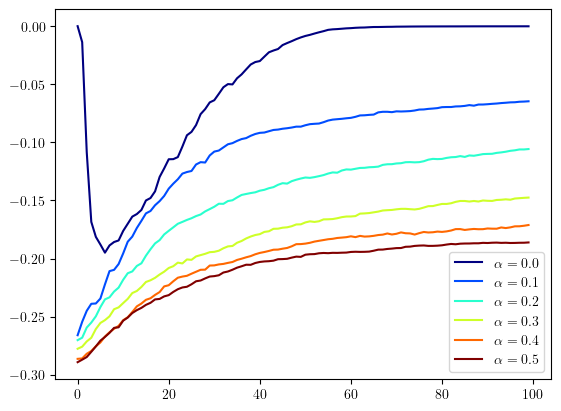

In [50]:
plt.figure()
n = 6
colors = plt.cm.jet(np.linspace(0,1,n))
for i in range(6):
    Load = "Data_sim_0"+str(i)+".npy"
    Data = np.load(Load)

    #Data_mean = np.mean(data, axis=0)
    Data_median = np.median(Data, axis=0)
    Label = r'$\alpha = 0.$'+rf'${i}$'
    plt.plot(Data_median, color = colors[i], label = Label)
    plt.legend()
    plt.savefig("t0"+str(i)+".png")